In [34]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

# (1D) Linear regression
**Task description:**
1. Сгенерировать синтетический набор точек вида *y = ax + b + noise*
2. Визуализировать результат с помощью matplotlib
3. Решить задачу линейной регрессии для этого набора точек
4. Найти параметры модели с помощью градиентного спуска
5. Сравните найденные параметры со значениями *(a,b)*

In [2]:
a = 5
b = 3

In [3]:
np.random.seed(0)
x = np.random.rand(100, 1)
noise = np.random.rand(100, 1)

y = a * x + b + noise

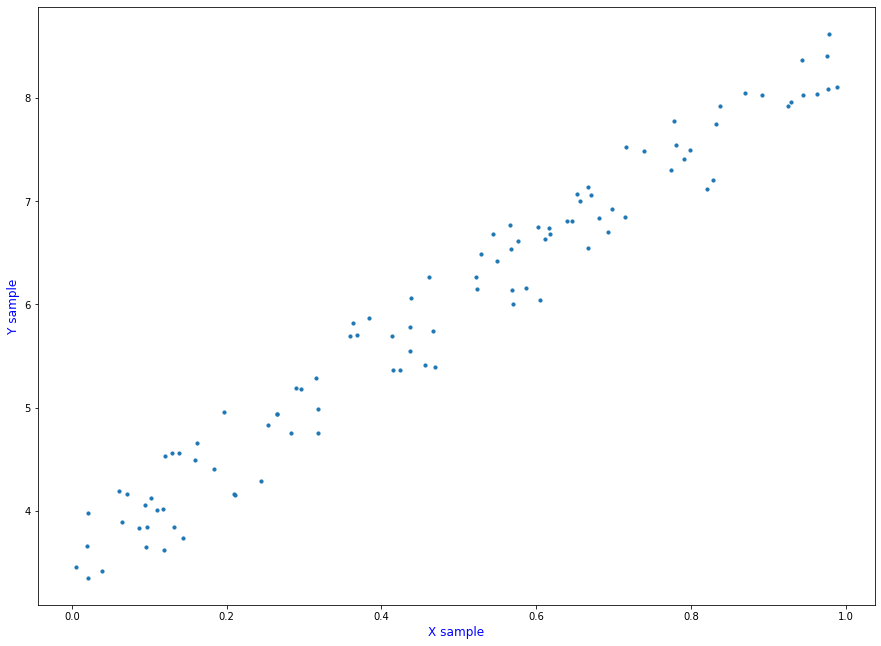

In [53]:
plt.figure(figsize=(15, 11))

plt.scatter(x, y, s=10)
plt.xlabel('X sample', fontsize=12, color='blue')
plt.ylabel('Y sample', fontsize=12, color='blue')
plt.show()

In [71]:
theta0 = 0
theta1 = 0

learning_rate = 0.01
n_iterations = 10000

n = len(x)

In [73]:
for i in range(n_iterations):
    y_current = theta1 * x + theta0
    theta0 -= (learning_rate / n) * sum(y_current - y)
    theta1 -= (learning_rate / n) * sum(x * (y_current - y))

In [7]:
print('Conditional weights:', 'a =', a, '\n', '                    b =', b)
print('\n')
print('Last weights:', '       a_theta1 =', theta1, '\n', '                    b_theta0 =', theta0)

Conditional weights: a = 5 
                     b = 3


Last weights:        a_theta1 = [4.93350506] 
                     b_theta0 = [3.55962366]


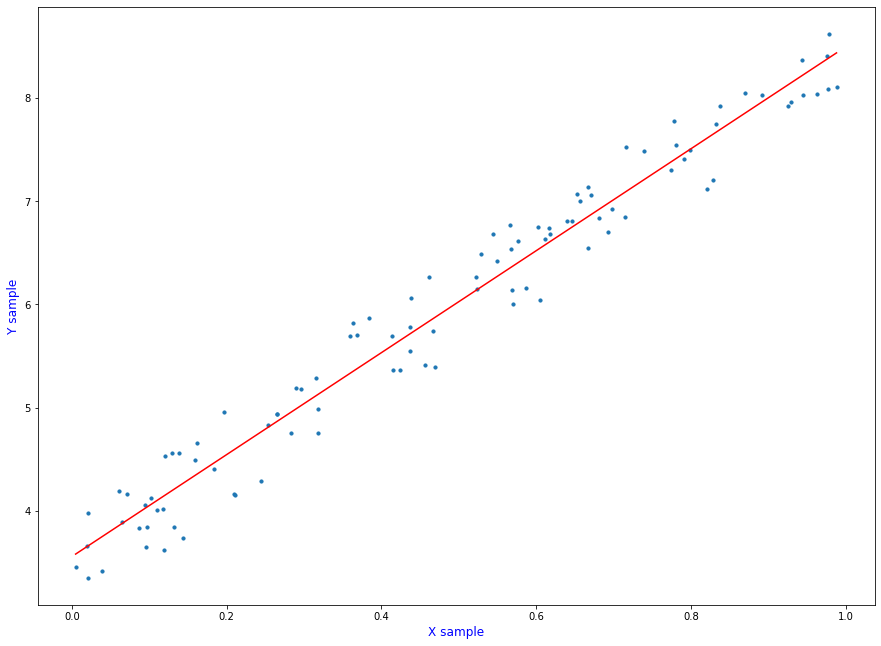

In [52]:
plt.figure(figsize=(15, 11))

y_current = theta1 * x + theta0

plt.scatter(x, y, s = 10)
plt.xlabel('X sample', fontsize=12, color='blue')
plt.ylabel('Y sample', fontsize=12, color='blue')
plt.plot([min(x), max(x)], [min(y_current), max(y_current)], color='red')
plt.show()

# (2D) Logistic regression
**Task description:**
1. Сгенерировать 2 сентетических набора точек на плоскости
2. Добавить метки классов (0 и 1) для этих наборов
3. Визуализировать результат с помощью matplotlib
4. Разделить данные на классы с помощью логистической регрессии
5. Проверить качество алгоритма с помощью метрики *accuracy*

In [61]:
np.random.seed(0)
num_points = 3000

mean_1 = [0, 0]
cov_1 = [[1, .5], [.5, 1]]
x1 = np.random.multivariate_normal(mean_1, cov_1, num_points)

mean_2 = [2, 5]
cov_2 = [[1, .5], [.5, 1]]
x2 = np.random.multivariate_normal(mean_2, cov_2, num_points)

_features = np.vstack((x1, x2)).astype(np.float32)
_labels = np.hstack((np.zeros(num_points), np.ones(num_points)))

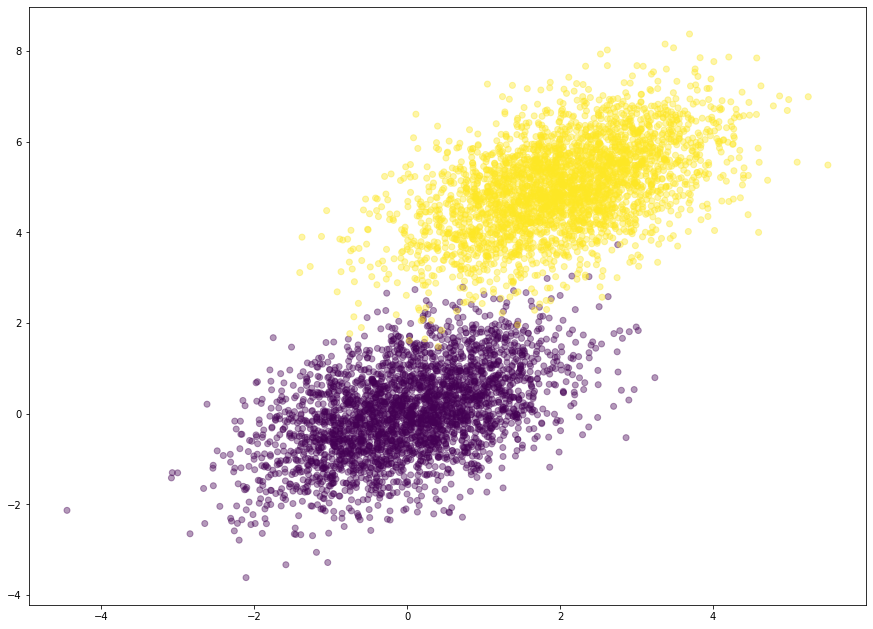

In [62]:
plt.figure(figsize=(15, 11))

plt.scatter(_features[:, 0], 
            _features[:, 1], 
            c = _labels, 
            alpha = .4)

In [63]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

In [74]:
def logistic_regression(features, target, num_iterations, learning_rate, add_intercept = False):
    
    if add_intercept:
        features_row_cnt = np.shape(features)[0]
        intercept = np.ones((features_row_cnt, 1))
        features = np.hstack((intercept, features))
    
    features_col_cnt = np.shape(features)[1]
    weights = np.zeros(features_col_cnt)
    
    for i in range(num_iterations):
        scores = np.dot(features, weights)
        predictions = sigmoid(scores)
        
        error = target - predictions
        gradient = np.dot(features.T, error)
        weights += learning_rate * gradient
    
    return weights

In [69]:
weigths = logistic_regression(_features, 
                              _labels, 
                              num_iterations = 100000, 
                              learning_rate = 5e-5,
                              add_intercept=True)

In [75]:
_features_row_cnt = np.shape(_features)[0]
intercept_data = np.hstack((np.ones((_features_row_cnt, 1)), _features))

final_scores = np.dot(intercept_data, weigths)
preds = np.round(sigmoid(final_scores))

print('Accuracy:', (preds == _labels).sum().astype(float) / len(preds))

Accuracy: 0.993
